## Example 2d:
Example workflow that trains a CNN-based mixture density network to predict the amplitude and
phase aberration coefficients from a single image (not a z-stack).

This model is specifically motivated by the fact that beam propagation is symmetric about
the focal plane if the even-`n` phase aberrations are simultaneously negated. Fitting a
z-stack provides enough information to resolve this degeneracy, but if the model only gets
an image at a single z-position, there are two equally-valid solutions. A mixture-density
model supports this multimodality, whereas a single, maximum likelihood estimator would
return the mean of zero.

Model trains itself using synthetic examples generated from the forwards model on-the-fly, with
the absolute focus position randomly jittered per example so the decoder learns to characterize
aberrations without relying on a precisely known nominal focus. A rigid focus shift is equivalent
to a superposition over the $Z_{2n}^0$ phase aberrations, so during training, the jittered
offset is folded into those phase labels.

To demonstrate the mixture's ability to represent multimodal posteriors, the nominal focus is pinned
at `z_objective = 0` so the focus jitter is symmetric about the focal plane. Symmetry about the
focal plane means the image then admits two equally-likely, symmetric solutions, which a 2-component
mixture can resolve.

In [1]:
import logging
import warnings

import torch
import pytorch_lightning as pl
from lightning_fabric.utilities.warnings import PossibleUserWarning
from matplotlib import pyplot

In [2]:
# Silence a few nuisance warnings:
logging.getLogger("pytorch_lightning").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=PossibleUserWarning)
warnings.filterwarnings("ignore", message="Starting from v1.9.0, `tensorboardX`")
warnings.filterwarnings("ignore", message=r".*isinstance\(treespec, LeafSpec\).*")

In [3]:
from cynosure.config_defaults import (
    get_default_training_config,
    get_default_simulation_config,
    get_default_optical_config,
    get_default_phase_config,
    get_default_amplitude_config,
    get_default_phase_prior,
    get_default_amplitude_prior,
    get_default_noise_config,
    get_default_mixture_config,
    get_default_velocity_config,
)
from cynosure.object_distribution import FixedBead
from cynosure.utilities.training_utils import NoValidationBar
from cynosure.utilities.visualization import (
    plot_correlation_matrix,
    plot_coefficient_uncertainties,
)
from cynosure.zstack_decoding import ZstackSolver_MixedDensity

#### Simulation setup

In [4]:
train_cfg = get_default_training_config()
sim_cfg = get_default_simulation_config()
opt_cfg = get_default_optical_config()
phase_cfg = get_default_phase_config()
amp_cfg = get_default_amplitude_config()
phase_prior = get_default_phase_prior()
amp_prior = get_default_amplitude_prior()
noise_cfg = get_default_noise_config()
vel_cfg = get_default_velocity_config()

object_distrib = FixedBead(sim_cfg, bead_diameter=0.1)
mixture_cfg = get_default_mixture_config()

In [5]:
rng_seed = 123
z_jitter = 1.0  # um
device = "cuda" if torch.cuda.is_available() else "cpu"

#### Solver setup and training

Set up the mixed density network with 2 components, in order to capture the anticipated 2-fold degeneracy about the focal plane. We could allow more components here, and the extra ones would either get starved of allocation or would become degenerate with one of the expected 2.

In [6]:
pl.seed_everything(rng_seed, workers=True)
solver = ZstackSolver_MixedDensity(
    train_cfg=train_cfg,
    sim_cfg=sim_cfg,
    optics_cfg=opt_cfg,
    phase_cfg=phase_cfg,
    amp_cfg=amp_cfg,
    phase_prior_cfg=phase_prior,
    amp_prior_cfg=amp_prior,
    object_distribution=object_distrib,
    z_objective=torch.zeros(1),
    z_jitter=z_jitter,
    mixture_cfg=mixture_cfg,
    noise_cfg=noise_cfg,
    hidden_channels=(8, 8),
    embedding_dims=32,
)
solver = solver.to(device)

Seed set to 123


In [7]:
trainer = pl.Trainer(
    max_epochs=40,
    accelerator=device,
    log_every_n_steps=50,
    callbacks=[NoValidationBar()],
)
trainer.fit(solver)
solver = solver.eval()

Sanity Checking: |                                                                                     | 0/? […

Training: |                                                                                            | 0/? […

#### Sanity checking the results

In [8]:
batch_size = 8
with torch.inference_mode():
    images, phase_coefs, amp_coefs = solver.simulator.create_examples(batch_size)
    pred_phase_coefs, pred_amp_coefs = solver.predict_coefficients(images)
    pred_images = solver.simulator.simulate_normalized_stacks(pred_phase_coefs, pred_amp_coefs)

As usual, our first check is to create labeled images; predict the coefficients from the images; and then use those coefficients to simulate predicted images, which should match the original images.

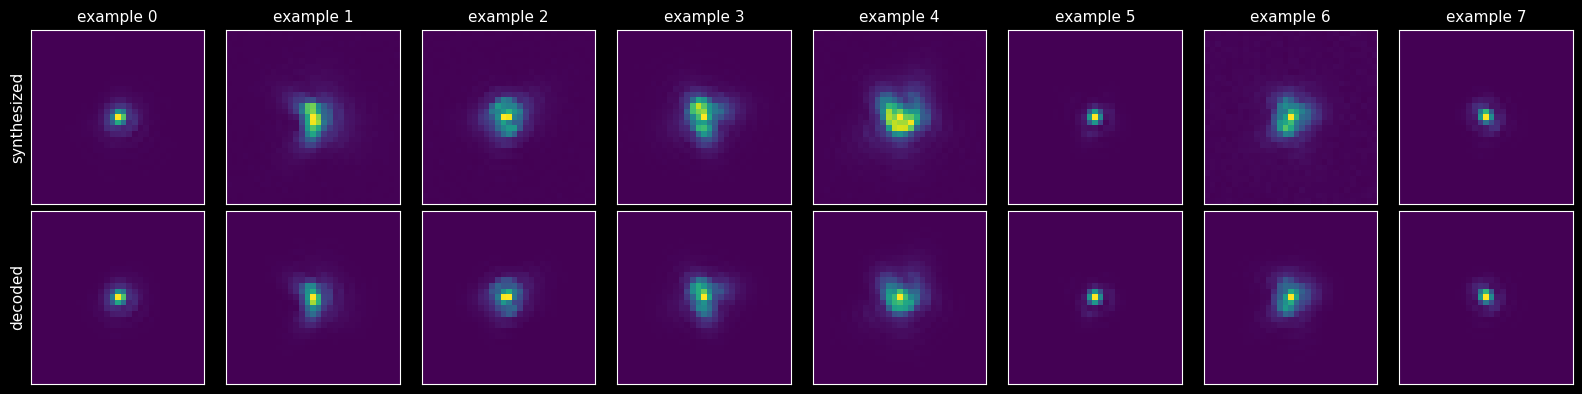

In [9]:
panel_size = 2
fig, axarr = pyplot.subplots(2, batch_size, figsize=(batch_size*panel_size, 2*panel_size))
for bidx in range(batch_size):
    ax1, ax2 = axarr[:, bidx]
    ax1.imshow(images.numpy(force=True)[bidx, 0])
    ax2.imshow(pred_images.numpy(force=True)[bidx, 0])
    ax1.set_title(f"example {bidx}", size=11)

for ax in axarr.ravel():
    ax.set_xticks([])
    ax.set_yticks([])
axarr[0, 0].set_ylabel("synthesized", size=11)
axarr[1, 0].set_ylabel("decoded", size=11)
fig.tight_layout()

#### Visualizing the predicted covariances

In [10]:
with torch.inference_mode():
    images, phase_coefs, amp_coefs = solver.simulator.create_examples(64*4)
    mixture_family = solver.predict_distribution(images)
    mixture = mixture_family.mixture_distribution
    dist = mixture_family.component_distribution

In [11]:
kept_labels = solver.coefficients.nonpinned_labels
num_kept_phase = solver.coefficients.num_nonpinned_in("phase")

covariances = dist.covariance_matrix
sigmas = covariances.diagonal(dim1=-2, dim2=-1).sqrt()
correlations = covariances / (sigmas.unsqueeze(-1) * sigmas.unsqueeze(-2))

Plot the coefficient covariance matrix as in example 2c, but now for each component independently. Since the system has two equally valid solutions, we expect to see two components at a 50/50 allocation split, with identical covariance matrices.

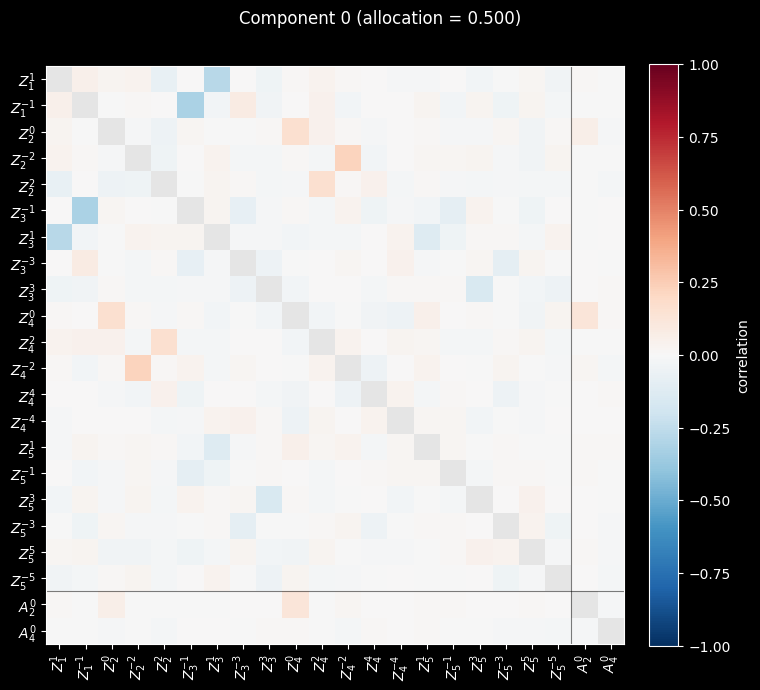

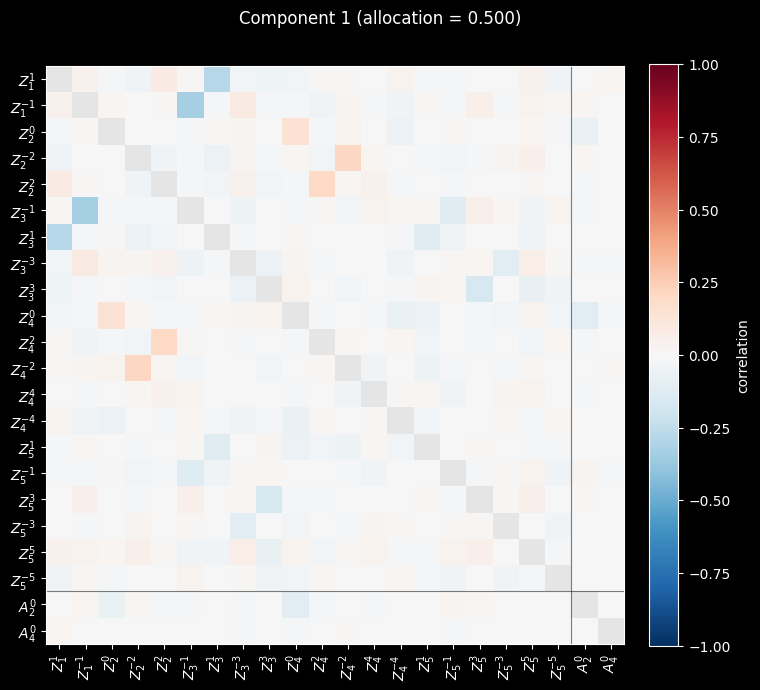

In [12]:
fig_list = [
    plot_correlation_matrix(
        correlations[:, i].mean(0).numpy(force=True),
        kept_labels,
        num_phase=num_kept_phase
    )
    for i in range(correlations.shape[1])
]
for i, (fig, alloc) in enumerate(zip(fig_list, mixture.probs.mean(0))):
    fig.suptitle(f'Component {i} (allocation = {alloc:.3f})')
    fig.tight_layout()

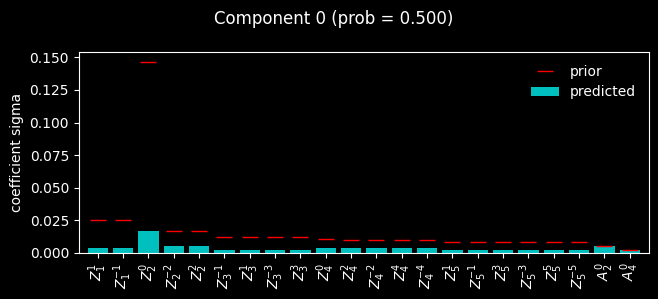

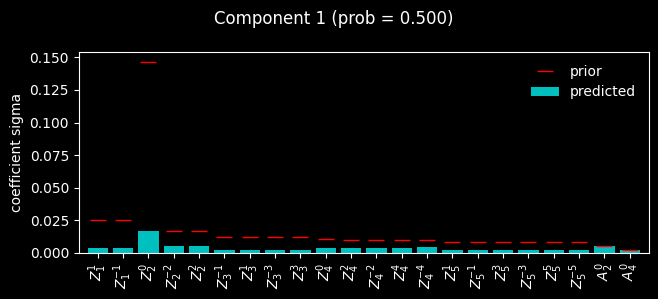

In [13]:
prior_sigmas = solver.coefficients.gather_nonpinned(solver.coefficients.target_scales)
fig_list = [
    plot_coefficient_uncertainties(
        sigmas[:, i].mean(0).numpy(force=True),
        prior_sigmas.numpy(force=True),
        kept_labels,
    )
    for i in range(correlations.shape[1])
]
for i, (fig, alloc) in enumerate(zip(fig_list, mixture.probs.mean(0))):
    fig.suptitle(f'Component {i} (prob = {alloc:.3f})')
    fig.tight_layout()

#### Visualizing the twin degeneracy

It occurs to me that I've just kind of declared that the symmetry about the focal plane exists, and left it as an exercise for the reader to prove. Here, we create a batch of labeled images, and then deliberately create their twins by negating the even-`n` coefficients (which negates the defocus in the process). Each image can then be shown to be identical to its twin, as well as to the image simulated from each component's predicted coefficients.

In [14]:
phase_is_even_n = solver.propagator.phase_projector.nm_indices[:, 0] % 2 == 0
amp_is_odd_n = solver.propagator.amp_projector.nm_indices[:, 0] % 2 == 1

def twin_coefficients(
        phase_coefs: torch.Tensor,
        amp_coefs: torch.Tensor,
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Returns the coefficients corresponding to the degenerate twin of the given ones.
    I.e., flips the signs of the even-n phases and the odd-n amplitudes.
    """
    return (
        torch.where(phase_is_even_n, -phase_coefs, phase_coefs),
        torch.where(amp_is_odd_n, -amp_coefs, amp_coefs),
    )

In [15]:
with torch.inference_mode():
    images, phase_coefs, amp_coefs = solver.simulator.create_examples(256)
    true_coefs = solver.coefficients.gather_nonpinned(solver.coefficients.join(phase_coefs, amp_coefs))
    img_truth = solver.simulator.simulate_normalized_stacks(phase_coefs, amp_coefs)

    twin_phase_coefs, twin_amp_coefs = twin_coefficients(phase_coefs, amp_coefs)
    twin_coefs = solver.coefficients.gather_nonpinned(solver.coefficients.join(twin_phase_coefs, twin_amp_coefs))
    img_twin = solver.simulator.simulate_normalized_stacks(twin_phase_coefs, twin_amp_coefs)

    _, comp_phase_coefs, comp_amp_coefs = solver.predict_component_coefficients(images[:batch_size])
    num_components = comp_phase_coefs.shape[1]
    comp_images = solver.simulator.simulate_normalized_stacks(
        comp_phase_coefs.reshape(batch_size*num_components, -1),
        comp_amp_coefs.reshape(batch_size*num_components, -1),
    ).unflatten(0, (batch_size, num_components))  # [batch_size, num_components, num_z, H, W]

Pick out 8 batch elements, and for each, plot the ground truth image; its twin from the outputs of `twin_coefficients()`; and the image predicted from each of the two components:

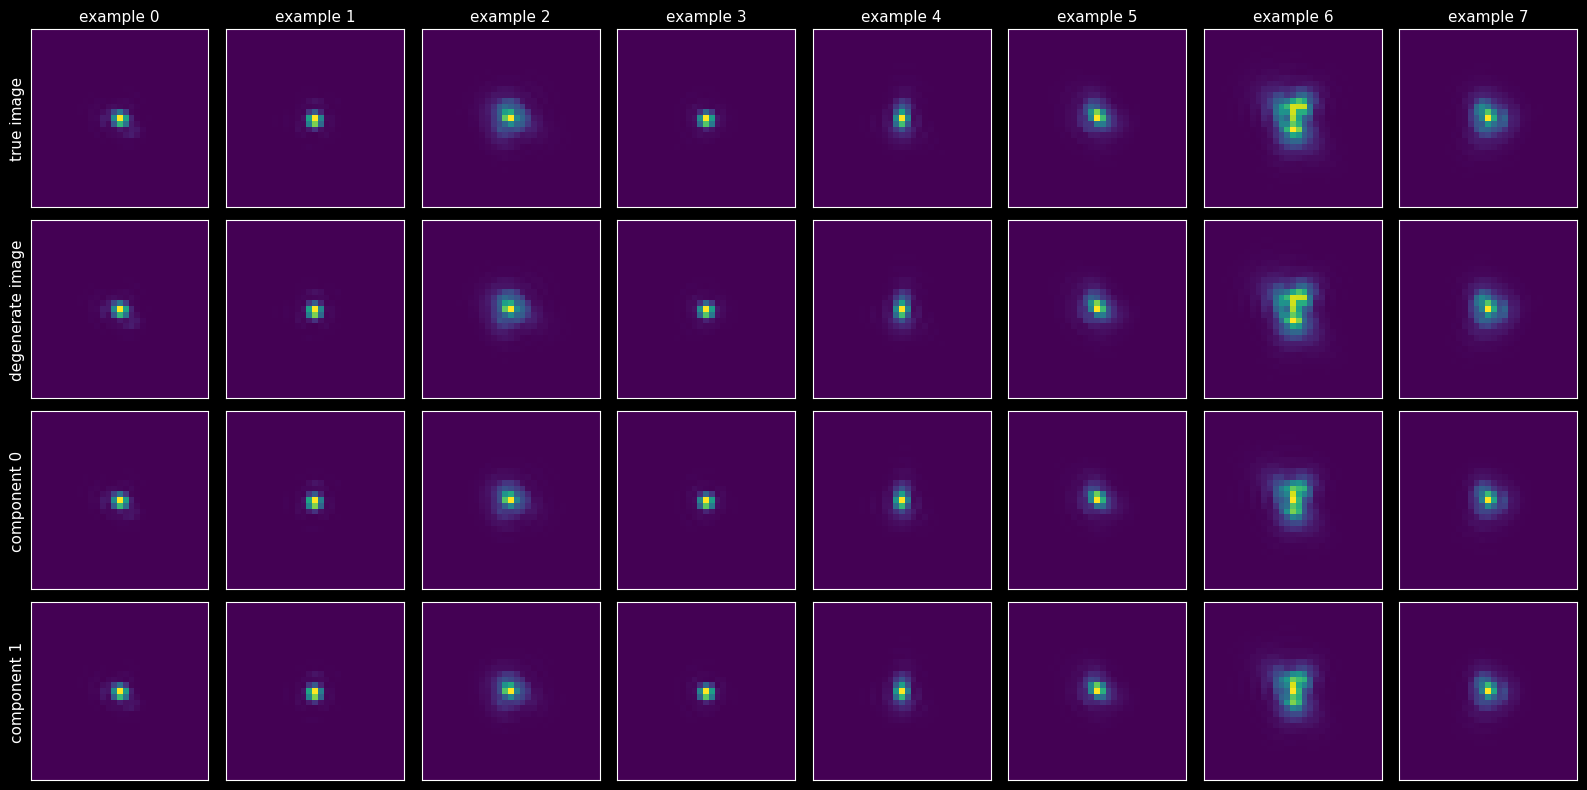

In [16]:
panel_size = 2
num_rows = 2 + num_components
figsize = (batch_size*panel_size, num_rows*panel_size)
fig, axarr = pyplot.subplots(num_rows, batch_size, figsize=figsize)
for bidx in range(batch_size):
    axarr[0, bidx].imshow(img_truth.numpy(force=True)[bidx, 0])
    axarr[1, bidx].imshow(img_twin.numpy(force=True)[bidx, 0])
    for k in range(num_components):
        axarr[2+k, bidx].imshow(comp_images.numpy(force=True)[bidx, k, 0])
    axarr[0, bidx].set_title(f"example {bidx}", size=11)

for ax in axarr.ravel():
    ax.set_xticks([])
    ax.set_yticks([])
axarr[0, 0].set_ylabel("true image", size=11)
axarr[1, 0].set_ylabel("degenerate image", size=11)
for k in range(num_components):
    axarr[2+k, 0].set_ylabel(f"component {k}", size=11)
fig.tight_layout()

To visualize the degeneracy another way, pick out from each image the two coefficients that differ most strongly from their twins, and plot the joint distribution between them. The two components should be clearly visible, coincident with the predicted means of each.

In [17]:
diff = (true_coefs - twin_coefs).abs()
dims_of_interest = diff.topk(2, dim=1).indices.sort(dim=1).values  # [B, 2] strongest twin-flipped coefs per example

with torch.inference_mode():
    mixture = solver.predict_distribution(images)
probs = mixture.mixture_distribution.probs.cpu()  # [B, K]
means = mixture.component_distribution.mean.cpu()  # [B, K, N]
covs = mixture.component_distribution.covariance_matrix.cpu()  # [B, K, N, N]

Example 1 (i.e. first row, second column) shows a the two peaks merging into a single, oblong, one. Based on the images plotted above, it looks like this one was close to being in perfect focus, causing the degeneracy to be close to collapsing.

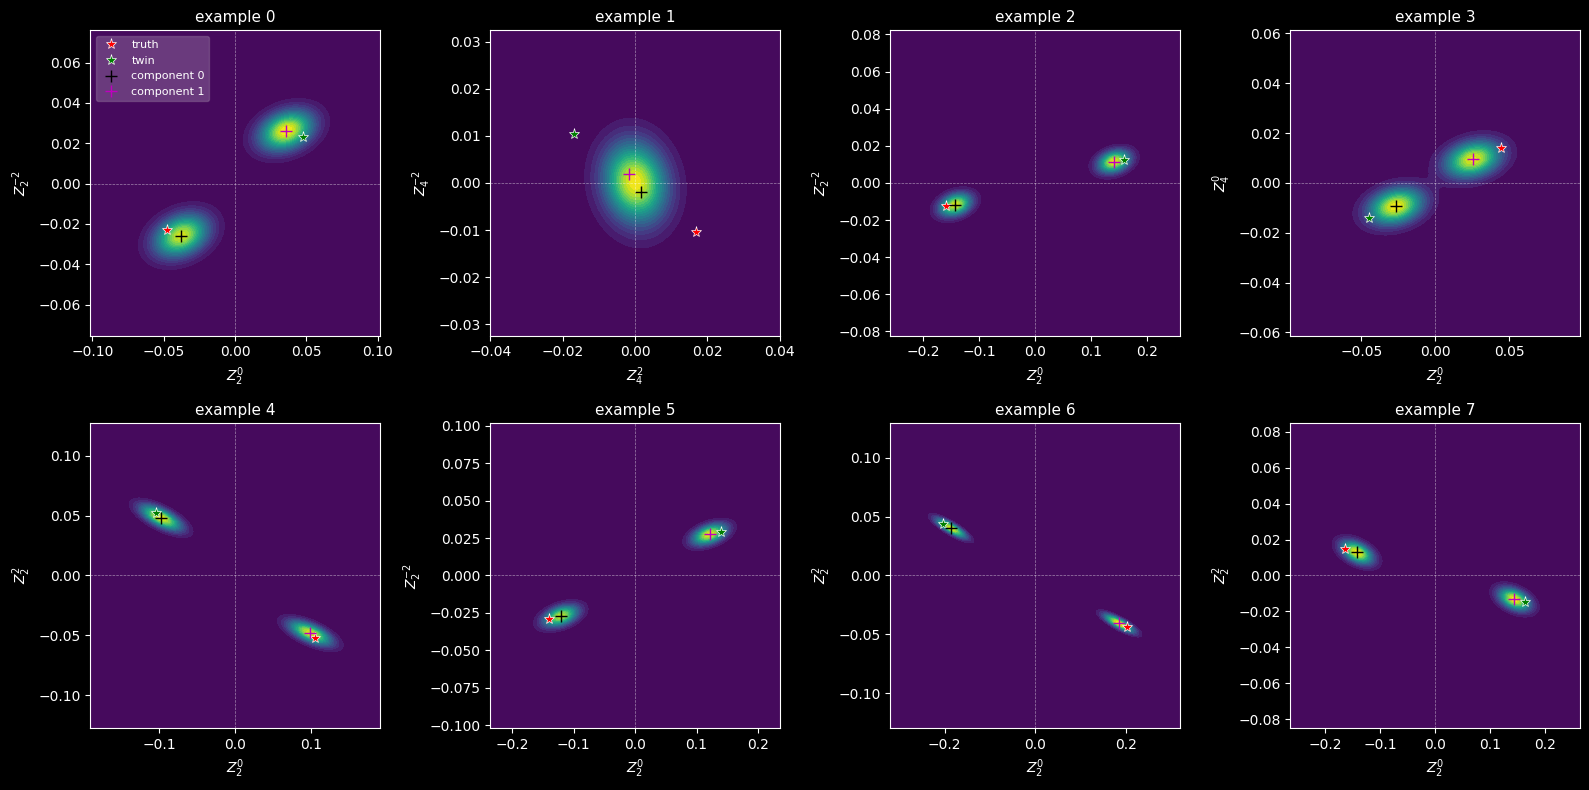

In [18]:
resolution = 201
panel_size = 4
fig, axarr = pyplot.subplots(2, batch_size//2, figsize=(batch_size//2*panel_size, panel_size*2))

for bidx, ax in enumerate(axarr.ravel()):
    dims = dims_of_interest[bidx].tolist()
    mu2 = means[bidx][:, dims]  # [K, 2]
    cov2 = covs[bidx][:, dims][:, :, dims]  # [K, 2, 2]

    anchors = torch.cat([mu2, true_coefs.cpu()[None, bidx, dims], twin_coefs.cpu()[None, bidx, dims]])
    spread = 3 * cov2.diagonal(dim1=-2, dim2=-1).sqrt().max()
    lo, hi = anchors.amin(0) - spread, anchors.amax(0) + spread

    grid_x = torch.linspace(lo[0].item(), hi[0].item(), resolution) * 1.2
    grid_y = torch.linspace(lo[1].item(), hi[1].item(), resolution) * 1.2
    mesh = torch.stack(torch.meshgrid(grid_x, grid_y, indexing="xy"), dim=-1)
    marginal = torch.distributions.MultivariateNormal(mu2, covariance_matrix=cov2)
    pdf = (probs[bidx] * marginal.log_prob(mesh.reshape(-1, 1, 2)).exp()).sum(-1).reshape(resolution, resolution)

    ax.contourf(grid_x.numpy(), grid_y.numpy(), pdf.numpy(force=True), levels=20)

    ax.plot(*true_coefs.numpy(force=True)[bidx, dims], "*", color="r", ms=8, label="truth", markeredgecolor="w", markeredgewidth=0.5)
    ax.plot(*twin_coefs.numpy(force=True)[bidx, dims], "*", color="g", ms=8, label="twin", markeredgecolor="w", markeredgewidth=0.5)

    ax.plot(*mu2.numpy(force=True)[0], "+", color="k", ms=8, label="component 0")
    ax.plot(*mu2.numpy(force=True)[1], "+", color="m", ms=8, label="component 1")

    ax.axhline(0, color="w", lw=0.5, ls="--", alpha=0.5)
    ax.axvline(0, color="w", lw=0.5, ls="--", alpha=0.5)
    ax.set_xlabel(kept_labels[dims[0]], size=10)
    ax.set_ylabel(kept_labels[dims[1]], size=10)
    ax.set_title(f"example {bidx}", size=11)

axarr[0, 0].legend(loc="upper left", fontsize=8, facecolor="w", framealpha=0.2)
fig.tight_layout()